### Mini Project 2
#### Team Members: Ledja Halltari & Sepehr Mansouri

In [72]:
%pip install imbalanced-learn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# Setup

np.random.seed(42) # Random seed for reproducibility
plt.style.use('default')
sns.set_palette("husl")

model_results = []


Note: you may need to restart the kernel to use updated packages.


In [73]:
DATA_PATH = "../data/diabetes.csv"
df = pd.read_csv(DATA_PATH)
print("data shape:", df.shape)
df.head()

data shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1) Data Preprocessing

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



- Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
No missing values! ✓

 Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

 Class Balance:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


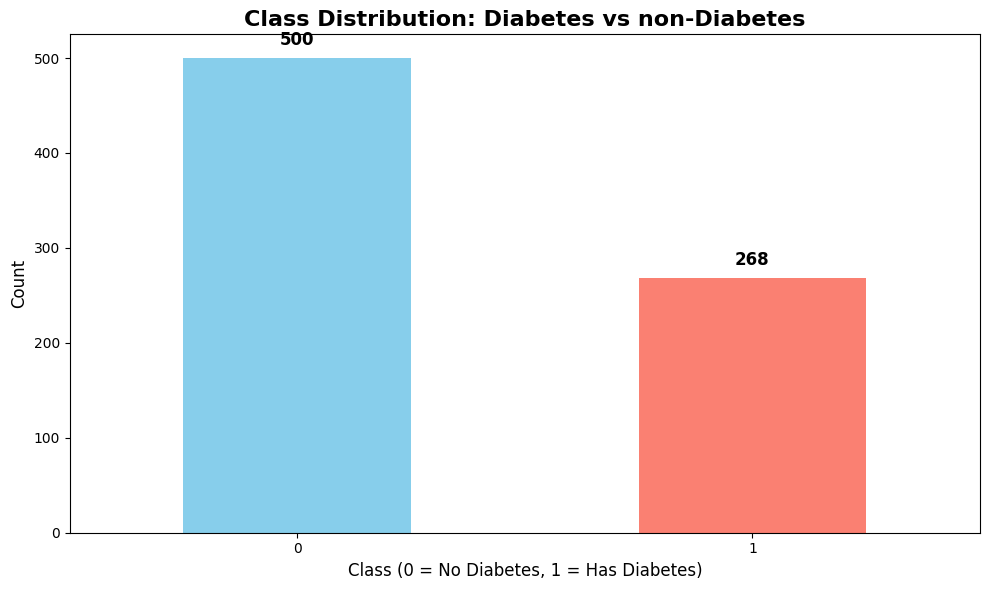

Number of diabetes cases: 268
Number of non-diabetes cases: 500
Imbalance Ratio (Non-Diabetes to Diabetes): 1.87
Diabetes Percentage: 34.89583333333333


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [74]:
display(df.head())

# Dataset info
print("\n- Dataset Information:")
print(df.info())

# Checking missing values
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values! ✓")

# Target Variable Distribution
print("\n Class Distribution:")
class_dist = df['Outcome'].value_counts()
print(class_dist)
print("\n Class Balance:")
class_pct = df['Outcome'].value_counts(normalize=True) * 100
print(class_pct)

X = df.drop('Outcome', axis=1)
y = df['Outcome']


plt.figure(figsize=(10, 6))
ax = df['Outcome'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution: Diabetes vs non-Diabetes', fontsize=16, fontweight='bold')
plt.xlabel('Class (0 = No Diabetes, 1 = Has Diabetes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)

# Add count labels on bars
for i, v in enumerate(class_dist.values):
    ax.text(i, v + 10, f'{v:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


diabetes_count = df['Outcome'].sum()
non_diabetes_count = len(df) - diabetes_count
imbalance_ratio = non_diabetes_count / diabetes_count

#  print statement of the bellow 3 printfs to something different
print(f"Number of diabetes cases: {diabetes_count}")
print(f"Number of non-diabetes cases: {non_diabetes_count}")
print(f"Imbalance Ratio (Non-Diabetes to Diabetes): {imbalance_ratio:.2f}")
print("Diabetes Percentage:", (diabetes_count / len(df)) * 100  )


# Stats Summary
display(df.describe())


# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#  Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




### EDA

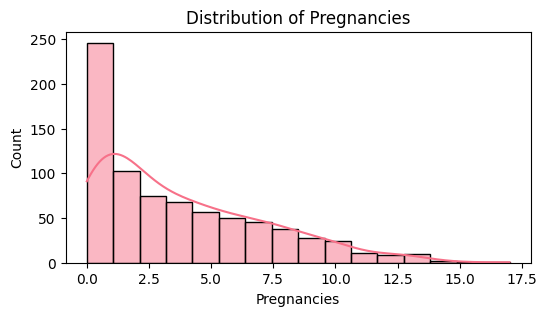

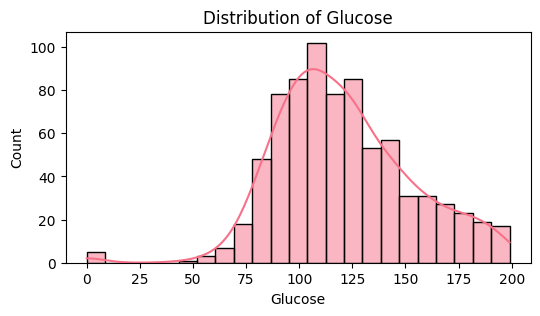

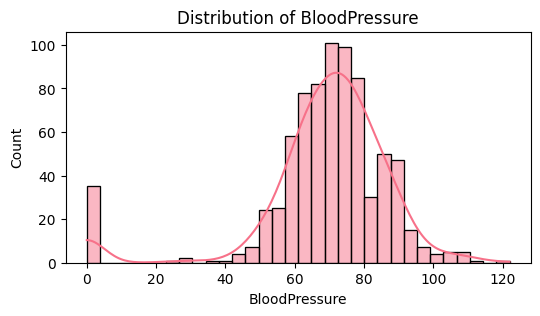

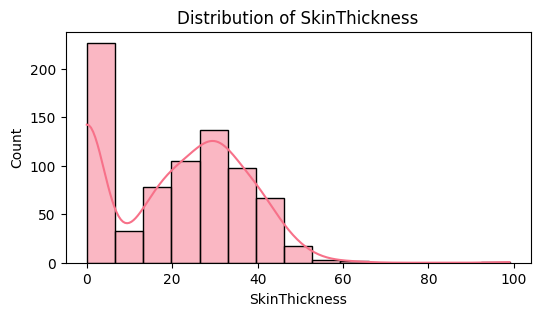

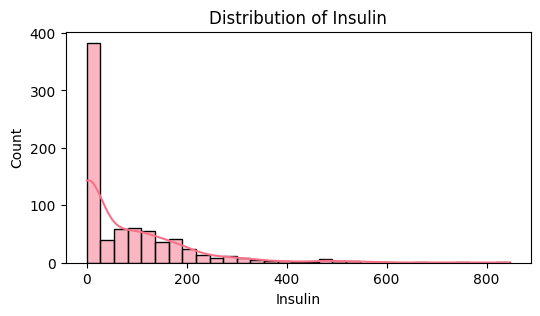

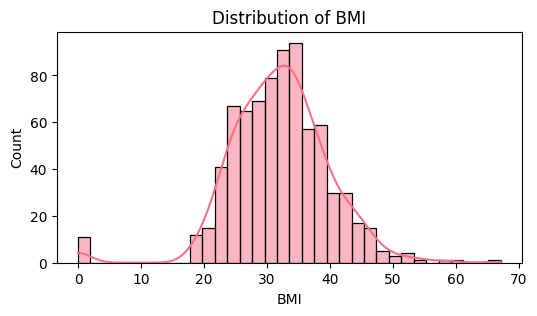

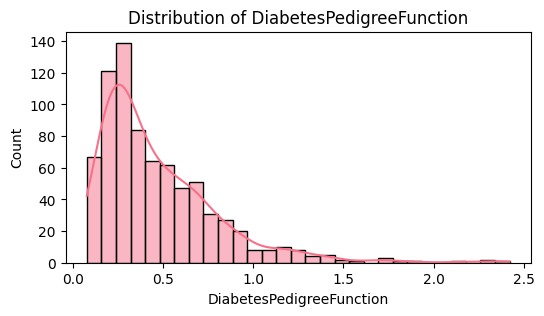

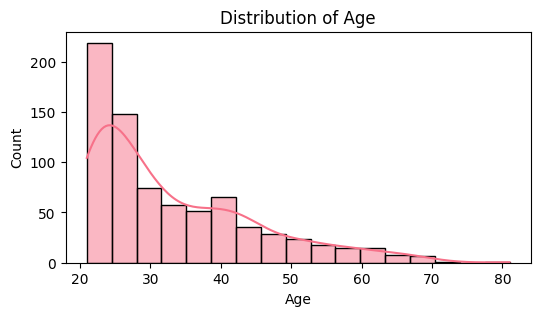

In [75]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_features:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()



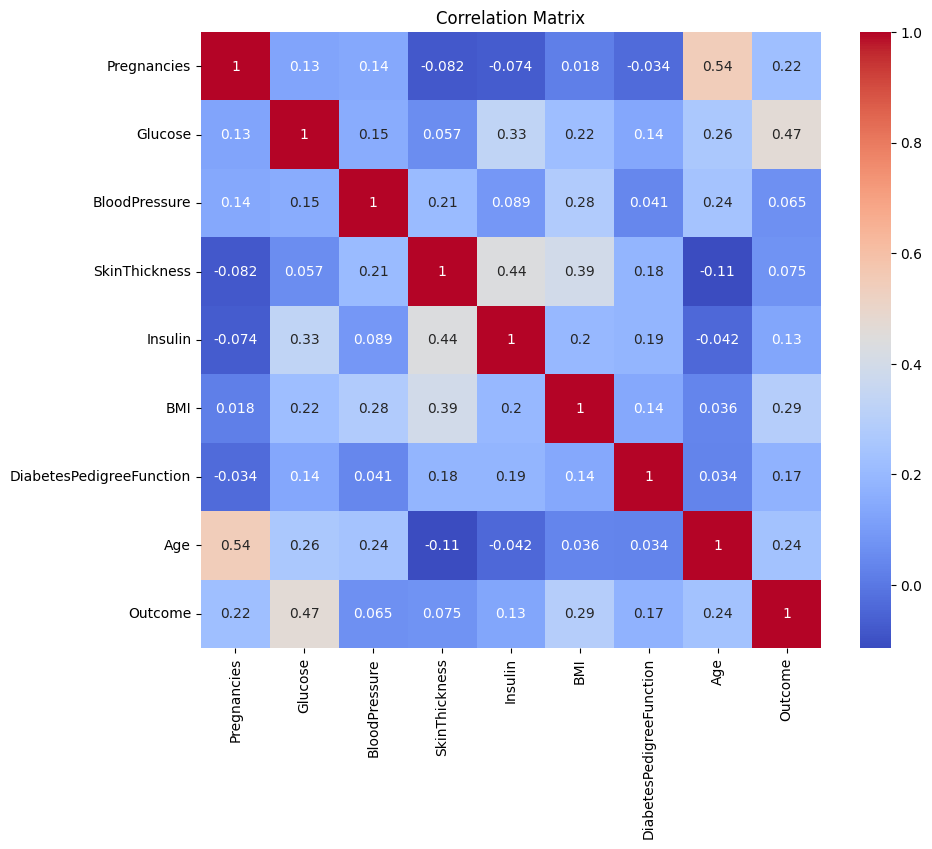

In [76]:
corr_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


## 2) Model Training

### i) Logistic Regression

In [77]:

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Generating Prediction
y_pred_log_reg = log_reg.predict(X_test_scaled)
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)

log_reg_report = classification_report(y_test, y_pred_log_reg, target_names=['Non-Diabetes', 'Diabetes'])

print("Logistic Regression training complete")
model_results.append({"model": "LogisticRegression", "accuracy": log_reg_accuracy, "report": log_reg_report})

print(model_results[0]["report"])


Logistic Regression training complete
              precision    recall  f1-score   support

Non-Diabetes       0.76      0.82      0.79       100
    Diabetes       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



### ii) Random Forest

In [78]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train) # Fitting Model
 
# Generating Prediction
y_pred_rf = rf.predict(X_test_scaled)

# Metrics calculations
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1_score = f1_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf, target_names=['Non-Diabetes', 'Diabetes'])


print("Random Forest training complete")
model_results.append({"model": "RandomForest", "accuracy": rf_accuracy, "f1_score": rf_f1_score, "report": rf_report})


Random Forest training complete


### iii) KNN

In [79]:
knn = KNeighborsClassifier( n_neighbors=100)
knn.fit(X_train_scaled, y_train)

y_predict_knn = knn.predict(X_test_scaled )

knn_accuracy = accuracy_score(y_test, y_predict_knn)
knn_f1_score = f1_score(y_test, y_predict_knn)
knn_report = classification_report(y_test, y_predict_knn, target_names=['Non-Diabetes', 'Diabetes'])

print('KNeighborsClassifier Training Complete')
print({"model": "RandomForest", "accuracy": rf_accuracy, "f1_score": rf_f1_score, "report": rf_report})

model_results.append({"model": "KNeighborsClassifier", "accuracy": knn_accuracy, "f1_score": knn_f1_score, "report": knn_report})

KNeighborsClassifier Training Complete
{'model': 'RandomForest', 'accuracy': 0.7597402597402597, 'f1_score': 0.6336633663366337, 'report': '              precision    recall  f1-score   support\n\nNon-Diabetes       0.79      0.85      0.82       100\n    Diabetes       0.68      0.59      0.63        54\n\n    accuracy                           0.76       154\n   macro avg       0.74      0.72      0.73       154\nweighted avg       0.75      0.76      0.76       154\n'}


## 3) Hyperparameter Tuning

In [80]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

print(param_grid)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_parameters = grid_search.best_params_
print("Best Parameters from Grid Search:", best_parameters)

best_f1_score = grid_search.best_score_
print("Best F1 Score from Grid Search:", best_f1_score)


{'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters from Grid Search: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 Score from Grid Search: 0.6342129858705811


## 4) Imbalanced Data Handling

### Confusion Matrix

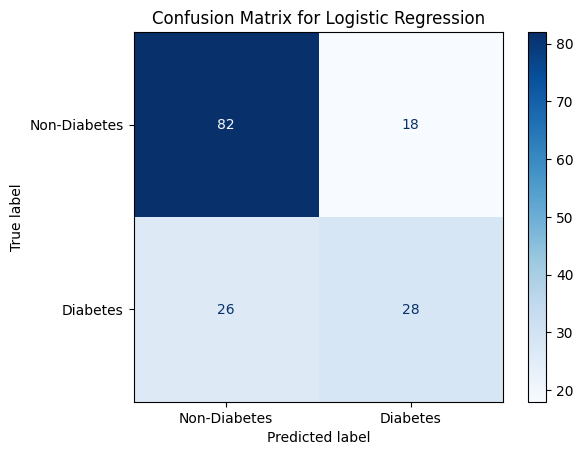

True Negatives (TN):  82 - Identified Diabetes correctly
False Positives (FP): 18 - Falely flagged as Diabetes
False Negatives (FN): 26 - Missed actual Diabetes cases
True Positives (TP):  28 - Correctly identified Diabetes cases


Diabetes Detection Performance:
Precision: 0.6087 - Out of all predictions we classified as fraud, 60.87% were actually fraud cases (measures false positive rate)
Recall:    0.5185 - Out of all actual fraud cases in the dataset, we successfully identified 51.85% of them (measures false negative rate)
F1 Score:  0.5600 - Balanced overall metric that combines precision and recall; ranges from 0 to 1 where higher is better


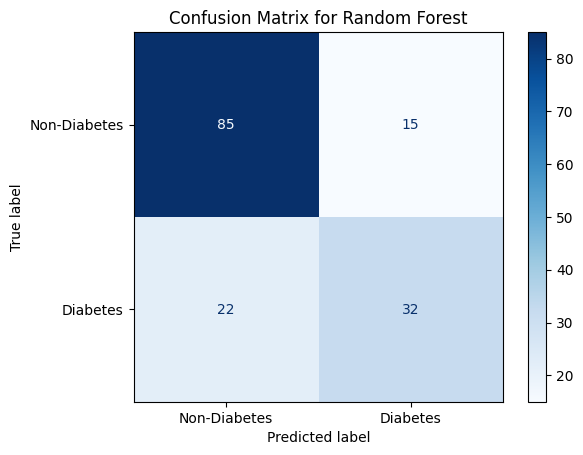

True Negatives (TN):  85 - Identified Diabetes correctly
False Positives (FP): 15 - Falely flagged as Diabetes
False Negatives (FN): 22 - Missed actual Diabetes cases
True Positives (TP):  32 - Correctly identified Diabetes cases


Diabetes Detection Performance:
Precision: 0.6809 - Out of all predictions we classified as fraud, 68.09% were actually fraud cases (measures false positive rate)
Recall:    0.5926 - Out of all actual fraud cases in the dataset, we successfully identified 59.26% of them (measures false negative rate)
F1 Score:  0.6337 - Balanced overall metric that combines precision and recall; ranges from 0 to 1 where higher is better


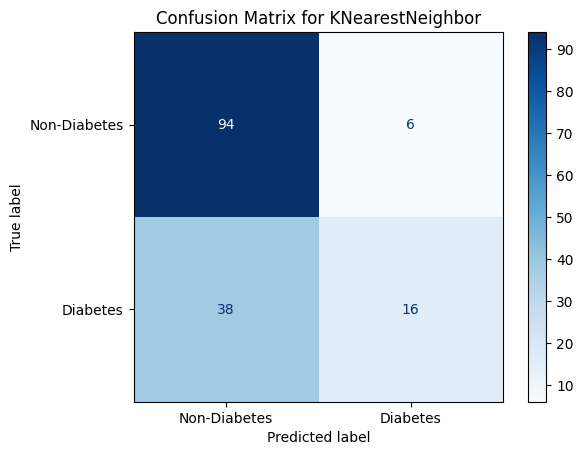

True Negatives (TN):  94 - Identified Diabetes correctly
False Positives (FP): 6 - Falely flagged as Diabetes
False Negatives (FN): 38 - Missed actual Diabetes cases
True Positives (TP):  16 - Correctly identified Diabetes cases


Diabetes Detection Performance:
Precision: 0.7273 - Out of all predictions we classified as fraud, 72.73% were actually fraud cases (measures false positive rate)
Recall:    0.2963 - Out of all actual fraud cases in the dataset, we successfully identified 29.63% of them (measures false negative rate)
F1 Score:  0.4211 - Balanced overall metric that combines precision and recall; ranges from 0 to 1 where higher is better


In [81]:
# do confusion matrix & visualization for all models
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrix_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetes', 'Diabetes'])
    confusion_matrix_display.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()
    fraud_precision = precision_score(y_test, y_pred, average='binary')
    fraud_recall = recall_score(y_test, y_pred, average='binary')
    fraud_f1 = f1_score(y_test, y_pred, average='binary')

    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives (TN):  {tn:,} - Identified Diabetes correctly")
    print(f"False Positives (FP): {fp:,} - Falely flagged as Diabetes")
    print(f"False Negatives (FN): {fn:,} - Missed actual Diabetes cases")
    print(f"True Positives (TP):  {tp:,} - Correctly identified Diabetes cases")

    print("\n")
    print("Diabetes Detection Performance:")
    print(f"Precision: {fraud_precision:.4f} - Out of all predictions we classified as fraud, {fraud_precision*100:.2f}% were actually fraud cases (measures false positive rate)")
    print(f"Recall:    {fraud_recall:.4f} - Out of all actual fraud cases in the dataset, we successfully identified {fraud_recall*100:.2f}% of them (measures false negative rate)")
    print(f"F1 Score:  {fraud_f1:.4f} - Balanced overall metric that combines precision and recall; ranges from 0 to 1 where higher is better")



# Logistic Regression Confusion Matrix
plot_confusion_matrix(y_test, y_pred_log_reg, "Logistic Regression")

# Random Forest Confusion Matrix
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")


# KNearestNeighbor Confusion Matrix
plot_confusion_matrix(y_test, y_predict_knn , "KNearestNeighbor") 



### ROC & AUC

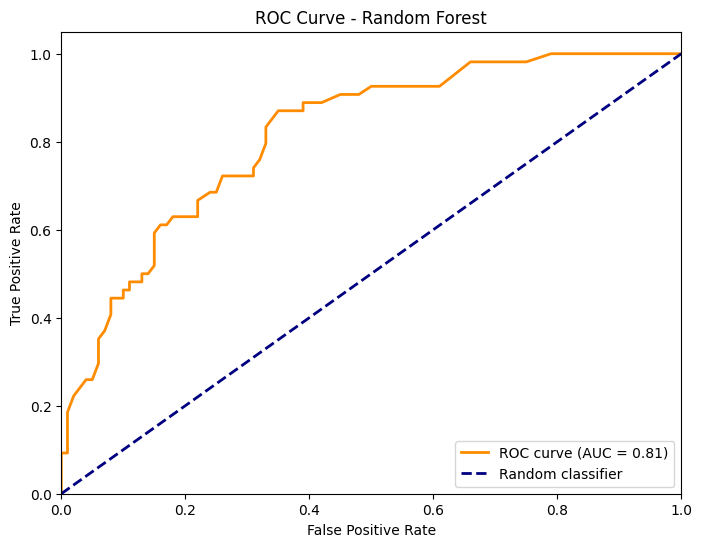

--------------------------------------------------
ROC-AUC Score: 0.8147


In [82]:
# Getting Probablility prediction from positive class
y_pred_probabability = rf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probabability)

# Calculating ROC & AUC
roc_auc = roc_auc_score(y_test, y_pred_probabability)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()

print("-"* 50)
print(f"ROC-AUC Score: {roc_auc:.4f}")

### Imbalanced Data Handling

Class Weighted Random Forest training complete
Original training set size: 614
SMOTE training set size: 800
Original class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64
SMOTE class distribution:
Outcome
0    400
1    400
Name: count, dtype: int64

SMOTE Random Forest training complete

IMBALANCED DATA HANDLING COMPARISON
              Approach  Accuracy  F1 Score
Baseline Random Forest  0.759740  0.633663
        Class Weighted  0.772727  0.646465
      SMOTE Resampling  0.733766  0.655462


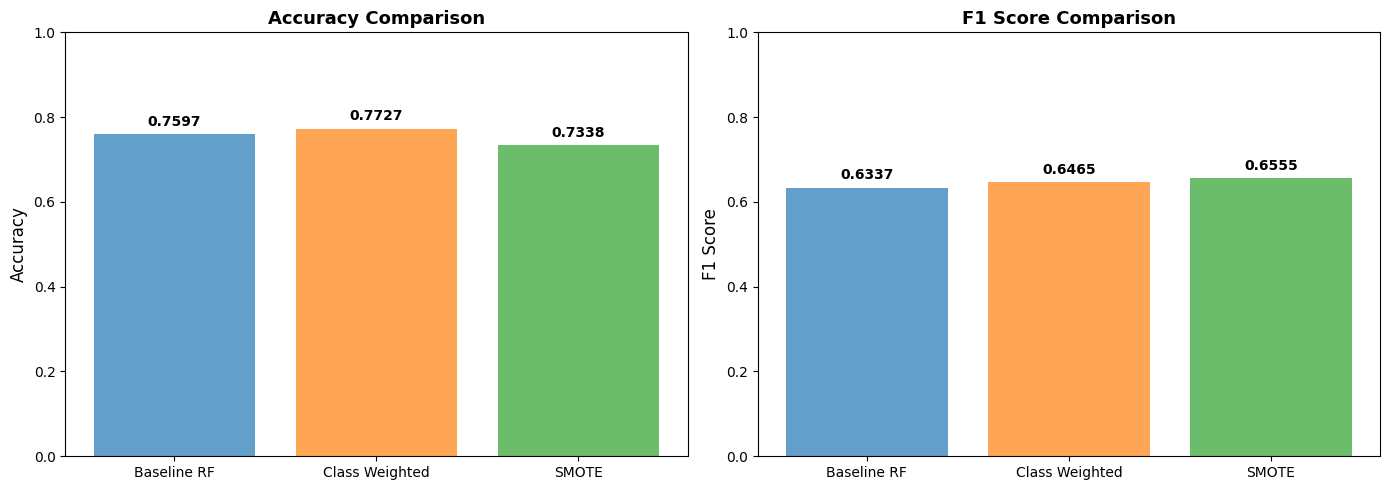

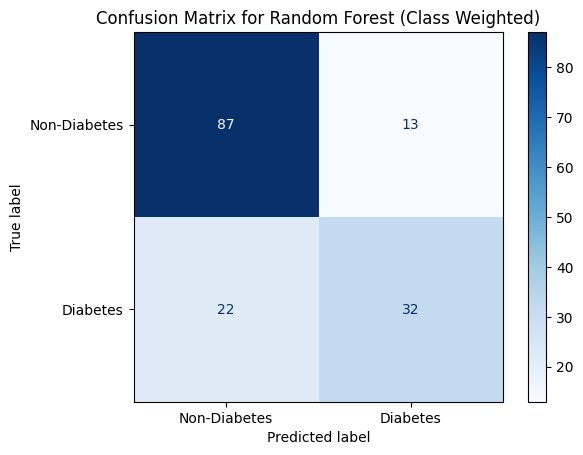

True Negatives (TN):  87 - Identified Diabetes correctly
False Positives (FP): 13 - Falely flagged as Diabetes
False Negatives (FN): 22 - Missed actual Diabetes cases
True Positives (TP):  32 - Correctly identified Diabetes cases


Diabetes Detection Performance:
Precision: 0.7111 - Out of all predictions we classified as fraud, 71.11% were actually fraud cases (measures false positive rate)
Recall:    0.5926 - Out of all actual fraud cases in the dataset, we successfully identified 59.26% of them (measures false negative rate)
F1 Score:  0.6465 - Balanced overall metric that combines precision and recall; ranges from 0 to 1 where higher is better


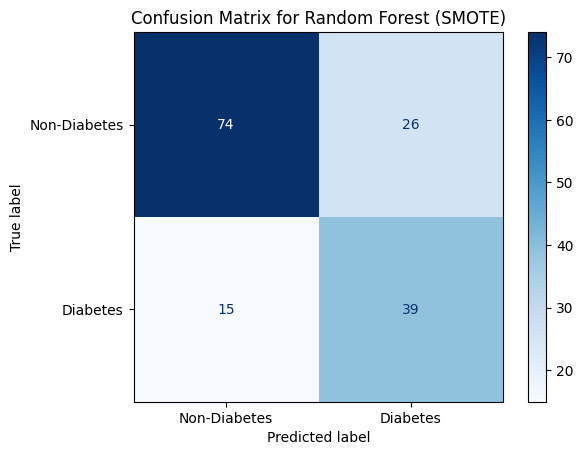

True Negatives (TN):  74 - Identified Diabetes correctly
False Positives (FP): 26 - Falely flagged as Diabetes
False Negatives (FN): 15 - Missed actual Diabetes cases
True Positives (TP):  39 - Correctly identified Diabetes cases


Diabetes Detection Performance:
Precision: 0.6000 - Out of all predictions we classified as fraud, 60.00% were actually fraud cases (measures false positive rate)
Recall:    0.7222 - Out of all actual fraud cases in the dataset, we successfully identified 72.22% of them (measures false negative rate)
F1 Score:  0.6555 - Balanced overall metric that combines precision and recall; ranges from 0 to 1 where higher is better

IMBALANCED DATA HANDLING - KEY INSIGHTS

✓ Best Approach (by F1 Score): SMOTE with F1 = 0.6555

F1 Score Improvements:
  Class Weighted: +0.0128 vs Baseline
  SMOTE:         +0.0218 vs Baseline


In [83]:
### Class Weights (Balanced)
df_weighted = RandomForestClassifier(class_weight='balanced', random_state=42)
df_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = df_weighted.predict(X_test_scaled)
weighted_accuracy = accuracy_score(y_test, y_pred_weighted)
weighted_f1 = f1_score(y_test, y_pred_weighted)
weighted_report = classification_report(y_test, y_pred_weighted, target_names=['Legitimate', 'Diabetes'])

print("Class Weighted Random Forest training complete")
model_results.append({
    "model": "RandomForest (Class Weighted)", 
    "accuracy": weighted_accuracy, 
    "f1_score": weighted_f1, 
    "report": weighted_report
})

### SMOTE Resampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set size: {X_train_scaled.shape[0]}")
print(f"SMOTE training set size: {X_train_smote.shape[0]}")
print(f"Original class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"SMOTE class distribution:\n{pd.Series(y_train_smote).value_counts()}")

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test_scaled)
smote_accuracy = accuracy_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote)
smote_report = classification_report(y_test, y_pred_smote, target_names=['Non-Diabetes', 'Diabetes'])

print("\nSMOTE Random Forest training complete")
model_results.append({
    "model": "RandomForest (SMOTE)", 
    "accuracy": smote_accuracy, 
    "f1_score": smote_f1, 
    "report": smote_report
})

### Comparison Summary
print("\n" + "="*60)
print("IMBALANCED DATA HANDLING COMPARISON")
print("="*60)
comparison_df = pd.DataFrame([
    {"Approach": "Baseline Random Forest", "Accuracy": rf_accuracy, "F1 Score": rf_f1_score},
    {"Approach": "Class Weighted", "Accuracy": weighted_accuracy, "F1 Score": weighted_f1},
    {"Approach": "SMOTE Resampling", "Accuracy": smote_accuracy, "F1 Score": smote_f1}
])
print(comparison_df.to_string(index=False))
print("="*60)


# Visualization: Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Comparison
approaches = ['Baseline RF', 'Class Weighted', 'SMOTE']
accuracies = [rf_accuracy, weighted_accuracy, smote_accuracy]
f1_scores = [rf_f1_score, weighted_f1, smote_f1]

axes[0].bar(approaches, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# F1 Score Comparison
axes[1].bar(approaches, f1_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].set_title('F1 Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 1])
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Confusion Matrices for Imbalanced Data Handling
plot_confusion_matrix(y_test, y_pred_weighted, "Random Forest (Class Weighted)")
plot_confusion_matrix(y_test, y_pred_smote, "Random Forest (SMOTE)")

# Summary Analysis
print("\n" + "="*70)
print("IMBALANCED DATA HANDLING - KEY INSIGHTS")
print("="*70)


# we can use a max function in case we add more approaches later

best_approach = max(
    [("Baseline RF", rf_f1_score), 
     ("Class Weighted", weighted_f1), 
     ("SMOTE", smote_f1)], 
    key=lambda x: x[1]
)

print(f"\n✓ Best Approach (by F1 Score): {best_approach[0]} with F1 = {best_approach[1]:.4f}")
print(f"\nF1 Score Improvements:")
print(f"  Class Weighted: +{(weighted_f1 - rf_f1_score):.4f} vs Baseline")
print(f"  SMOTE:         +{(smote_f1 - rf_f1_score):.4f} vs Baseline")
print("="*70)

## 5) Model Evaluation

In [84]:
for result in model_results:
    print(f"Model: {result['model']}")
    print(f"Accuracy: {result['accuracy']:.4f}")
    if 'f1_score' in result:
        print(f"F1 Score: {result['f1_score']:.4f}")
    print("Classification Report:")
    print(result['report'])
    print("=" * 50)
    print("\n")

Model: LogisticRegression
Accuracy: 0.7143
Classification Report:
              precision    recall  f1-score   support

Non-Diabetes       0.76      0.82      0.79       100
    Diabetes       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



Model: RandomForest
Accuracy: 0.7597
F1 Score: 0.6337
Classification Report:
              precision    recall  f1-score   support

Non-Diabetes       0.79      0.85      0.82       100
    Diabetes       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



Model: KNeighborsClassifier
Accuracy: 0.7143
F1 Score: 0.4211
Classification Report:
              precision    recall  f1-score   support

Non-Diabetes       0.71      0.94      0.81       100
    D

## 6) Analysis